---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
echo: False
warning: False

---

# Titanic Survival Analysis

This analysis of the Titanic dataset aims to identify the key predictive features and variable interactions that most strongly influenced passenger survival outcomes. Moving beyond basic metrics such as class and gender, the study applies a detailed Exploratory Data Analysis (EDA) to uncover subtle patterns and relationships within the data.

Using visualizations and feature engineering, the analysis explores how Age, Passenger Class, Cabin Location, Gender, and Family Status interact to shape survival probability. These variables are later evaluated for their feature importance in classification, providing insights into which factors carried the greatest predictive weight in determining survival likelihood.

The result is a data-driven, reproducible framework that blends statistical reasoning and visualization to highlight both the human and analytical dimensions of the Titanic tragedy, serving as a compelling, end-to-end project for a data science portfolio.  

#### The dataset used can be downloaded from the following:
- [Kaggle Titanic Competition](https://www.kaggle.com/c/titanic/data)



---

### Exploring the Data


In [1]:
#Add Pandas library and open the file
import pandas as pd
from pandas import Series, DataFrame

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Setup the CSV as a DataFrame
titanic_df = pd.read_csv('../data/train.csv')

# Preview the data
titanic_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Reviewing the Data for Anomalies

---

In [2]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Data Context: Out of 891 total passengers**

- Age had 714 non-null values
- Cabin had 204 non-null values
- Embarked had 889 non-null values

*This context is important, as missing data can influence both distribution analysis and survival modeling.*

### Analyzing the Data

---

#### Review the Data Male vs Female Distribution by Passenger Class

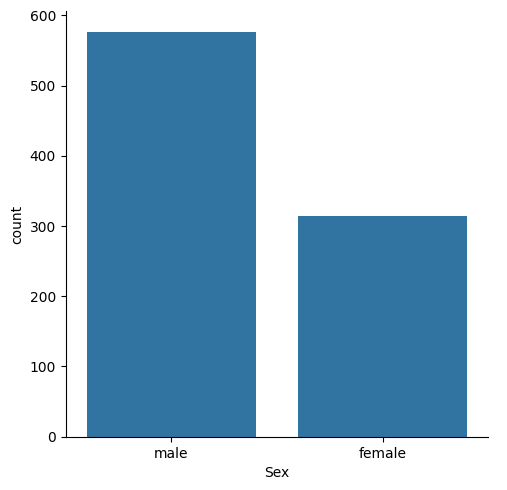

In [3]:
sns.catplot(x='Sex',data=titanic_df,kind='count');

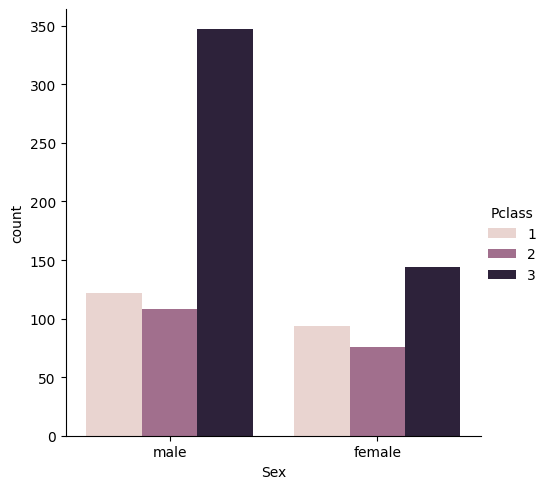

In [4]:
sns.catplot(x='Sex', data=titanic_df, hue='Pclass', kind='count');

**Gender Distribution Across Passenger Classes**

The dataset shows a skewed gender distribution, with a higher number of male passengers overall.

- **Male Passengers:** The distribution of male passengers is relatively balanced between first and second class, with the highest concentration in third    class.

- **Female Passengers:** Female passengers are more evenly spread across first and second class. While there are more females in third class than in the other classes, their numbers remain significantly lower than male passengers in third class.

This distribution highlights potential demographic and social patterns among passengers, which may intersect with survival outcomes when analyzed alongside class and other factors.

#### Male vs Female Comparison by Passenger Class

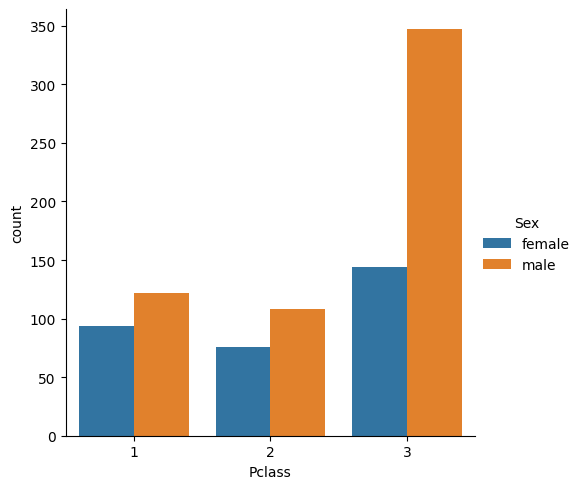

In [5]:
sns.catplot(x='Pclass', data=titanic_df, hue='Sex', kind='count');

---

#### Adding the “Person” Column to Distinguish Children from Adults

In this step, a new feature called person was created to classify passengers as either children or adults, with children defined as those under the age of 16. This transformation allows us to examine whether age group influenced survival probability.

The next analysis will compare the survival rates of children versus adults, particularly focusing on those traveling alone. It’s important to note that the Age column contains 177 missing values, which may introduce some bias or uncertainty into the results. These missing values will be considered when interpreting the findings.

In [6]:
# Function Checks a passenger to determine if it's a child or adult
# if the passengers age is less than 16 it's a child else keep gender
# the new column person is populated with the return value

def male_female_child(passenger):
    age,sex = passenger

    if age < 16:
        return 'child'
    else:
        return sex

In [7]:
#Creates a new column 'person' to the data frame, then uses Age and Sex columns, and uses the apply method to call the function
# The Age and Sex values are passed to the male_female_child function, because axis=1, it does this for each row.

titanic_df['person'] = titanic_df[['Age','Sex']].apply(male_female_child,axis=1)

In [8]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male


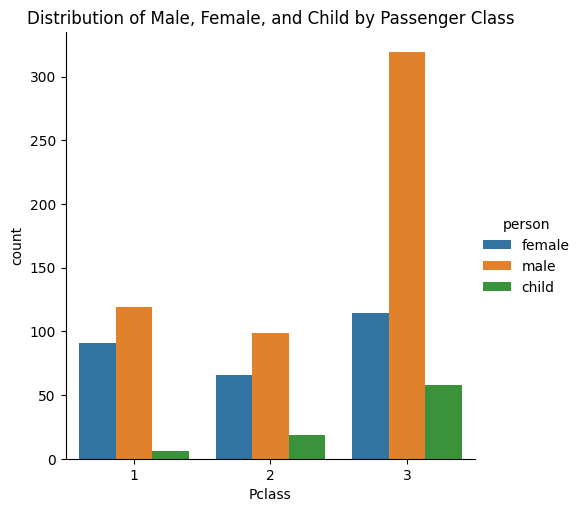

In [9]:
sns.catplot(x='Pclass',data=titanic_df,hue='person', kind='count')
plt.title('Distribution of Male, Female, and Child by Passenger Class');

#### Analyze the Distribution of Children vs Adults
- Children make up a small portion of the passengers on the Titanic
    - 83 per the histogram below
- Adults make up approximately 7/8th of the passengers on the Titanic
    - 537 Males
    - 271 Females

#### Age Histogram

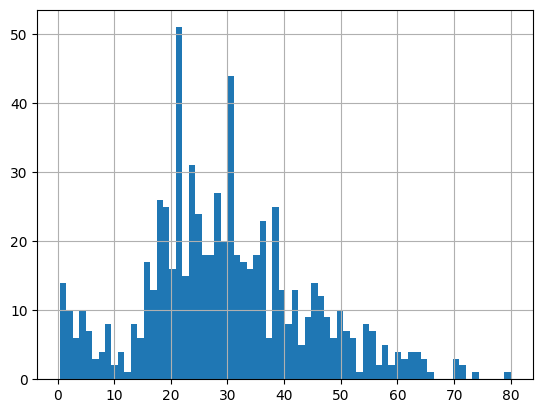

In [10]:
titanic_df['Age'].hist(bins=70)
plt.show()

**This histogram illustrates the age distribution of passengers on the Titanic**

The distribution is right-skewed, indicating a clear majority of passengers were young adults and middle-aged individuals. The most dominant age group appears to be between 20 and 40 years old, with a strong peak around the mid-20s to early-30s. There is also a secondary, smaller peak for children (under 10 years old). The frequency of passengers steadily decreases after the mid-40s, with very few passengers over the age of 65. This distribution is typical of the demographics expected for an early 20th-century trans-Atlantic voyage.

In [11]:
titanic_df['Age'].mean()

np.float64(29.69911764705882)

In [12]:
titanic_df['person'].value_counts()

person
male      537
female    271
child      83
Name: count, dtype: int64

---

#### Age Distribution Analysis using KDE

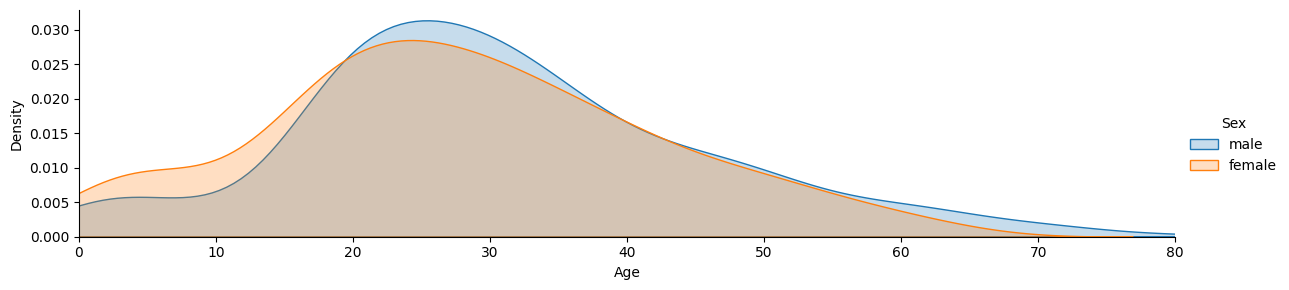

In [13]:
fig = sns.FacetGrid(titanic_df, hue= 'Sex',aspect= 4)
fig.map(sns.kdeplot,'Age',fill= True)

oldest = titanic_df['Age'].max()

fig.set(xlim =(0,oldest))
fig.add_legend();

The Adult population density illustrates that most adult passengers are concentrated between 20-35.

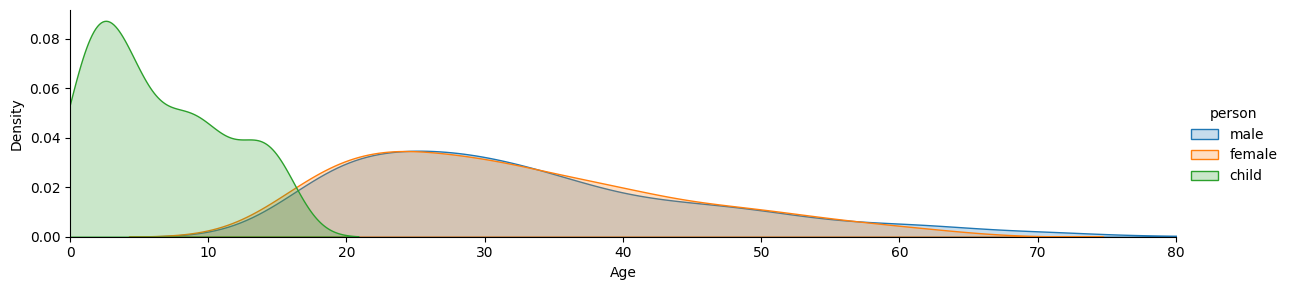

In [14]:
fig = sns.FacetGrid(titanic_df, hue='person',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest = titanic_df['Age'].max()

fig.set(xlim=(0,oldest))
fig.add_legend();

The children who were board the Titanic were mostly less than 10 years old.

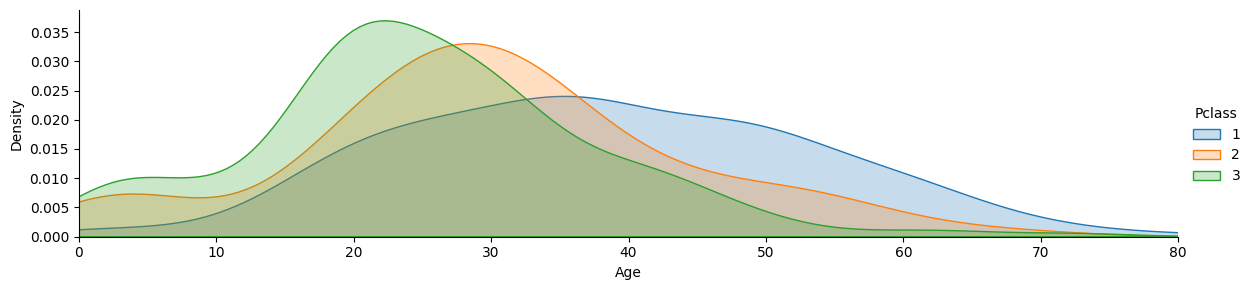

In [15]:
fig = sns.FacetGrid(titanic_df, hue='Pclass',aspect=4)
fig.map(sns.kdeplot,'Age',fill=True)

oldest = titanic_df['Age'].max()

fig.set(xlim=(0,oldest))
fig.add_legend();

The distributions indicate that the majority of passengers across all classes were between 15 and 35 years old, with the density curves peaking in this age range. Passengers over 40 years old were primarily concentrated in first class, suggesting a demographic skew toward older, more affluent travelers. In contrast, third-class distributions were heavily weighted toward younger passengers, with very few individuals over 50.

The KDE (Kernel Density Estimate) plot of Passenger Class vs. Age highlights distinct density concentrations across classes:

- First Class: Broad age distribution spanning 15–60 years, with moderate density among middle-aged passengers.

- Second Class: Narrower concentration around 20–40 years, reflecting a younger demographic profile.

- Third Class: Strong density between 15–30 years, indicating the youngest passenger population overall.

These patterns suggest age and class are moderately correlated, where socioeconomic factors likely influenced both travel class and, indirectly, survival probability. This insight provides a basis for further feature interaction analysis in subsequent steps.

In [16]:
deck = titanic_df['Cabin'].dropna()

In [17]:
#| output: False
deck.head()

1      C85
3     C123
6      E46
10      G6
11    C103
Name: Cabin, dtype: object

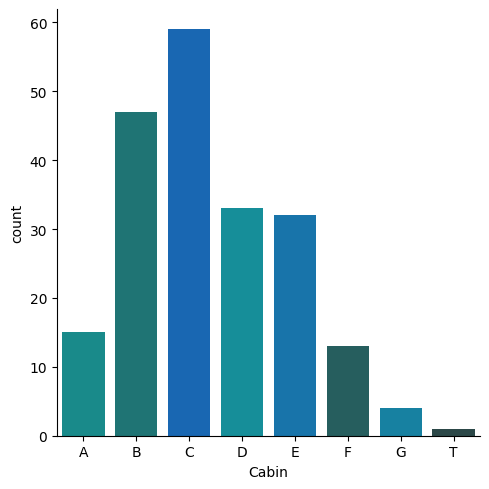

In [18]:
#| output: False
levels = []

for level in deck:
    levels.append(level[0])

cabin_df = DataFrame(levels)
cabin_df.columns = ['Cabin']
sns.catplot(x='Cabin', data=cabin_df,hue='Cabin', order=['A','B','C','D','E','F','G','T'], palette='winter_d',kind='count');

#### Distribution of Passengers by Cabin Level

To investigate whether cabin level influenced survival, we first explored how passengers were distributed across the various decks. Understanding this distribution provides context for any patterns in survival outcomes. Next, we analyzed the relationship between cabin level and survival rates to determine if certain decks offered a higher likelihood of survival, highlighting potential insights into class, location, and accessibility factors.

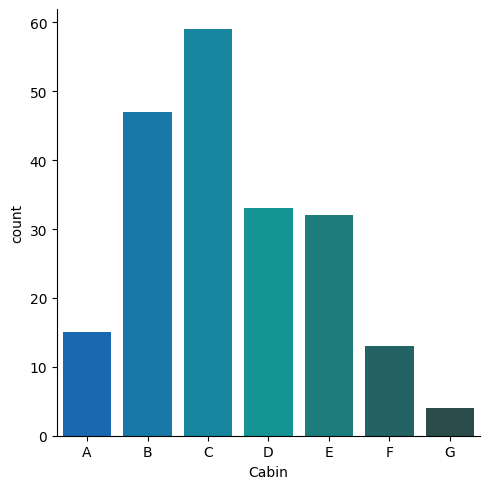

In [19]:
cabin_df = cabin_df[cabin_df.Cabin != 'T']

sns.catplot(x='Cabin',
            data=cabin_df.sort_values('Cabin'),
            hue='Cabin',
            palette='winter_d',
            kind='count',
            order=sorted(cabin_df['Cabin'].unique()));

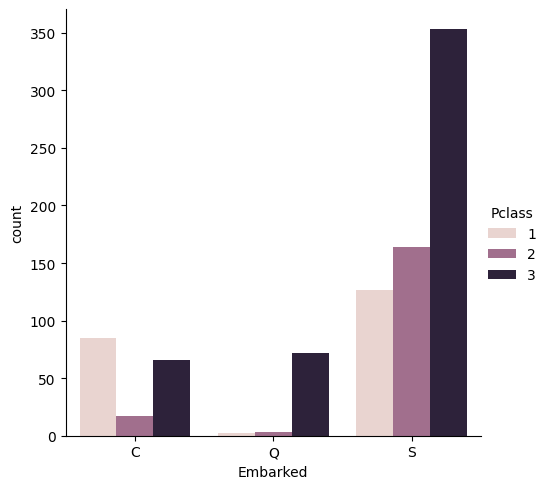

In [20]:
sns.catplot(x='Embarked',data=titanic_df,hue='Pclass',order=['C','Q','S'],kind='count');

**Passenger Distribution and Survival Factors**

To investigate factors that may have influenced survival, we examined both cabin level and port of embarkation.

**Cabin Level:** First, we analyzed how passengers were distributed across different cabin decks. Notably, the Cabin feature had a high proportion of missing values, with only 204 non-null entries out of 891 passengers. Despite this limitation, we explored the relationship between cabin level and survival to assess whether certain decks offered a higher likelihood of survival, potentially reflecting class, location, or accessibility factors.

**Port of Embarkation:** Next, we examined passenger counts by embarkation port to see if boarding location played a role in survival. Most passengers boarded at Southampton, while Cherbourg and Queenstown contributed far fewer passengers (889 non-null entries). This uneven distribution hints at potential differences in demographics or class composition across ports. By analyzing survival rates by embarkation port, we can explore whether these factors intersected with other risk variables, providing a more complete understanding of survival dynamics.

In [21]:
titanic_df['Alone'] = titanic_df.SibSp + titanic_df.Parch

In [22]:
#| output: False
titanic_df['Alone']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: Alone, Length: 891, dtype: int64

In [23]:
# Define Alone based on SibSp + Parch
titanic_df['Alone'] = np.where(
    (titanic_df['SibSp'] + titanic_df['Parch']) > 0,
    'With Family',
    'Alone'
)



In [24]:
#| output: False
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,With Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,With Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,With Family
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,Alone


#### Breaking Down the Survivors

To gain deeper insight into passenger survival patterns, I engineered a new feature called Alone by combining the existing columns SibSp (number of siblings/spouses aboard) and Parch (number of parents/children aboard).

If the sum of these two values is greater than zero, it suggests the passenger was traveling with family; otherwise, they were traveling alone. This binary feature helps us better understand how companionship might have impacted survival outcomes.

The visualization above shows that a larger portion of passengers traveled alone compared to those accompanied by family members. In the next section, we’ll analyze survival counts across these two groups to determine whether traveling alone influenced the likelihood of survival.

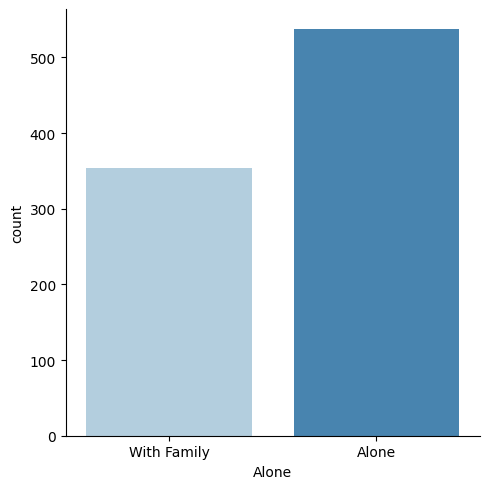

In [25]:
sns.catplot(x='Alone',data=titanic_df,hue='Alone',palette='Blues',kind='count');

The visualization indicates that approximately 350 passengers were traveling with family, while about 550 were traveling alone.
When examining survival outcomes, roughly 350 passengers survived in total. This preliminary observation suggests a potential positive correlation between traveling with family and survival likelihood during the Titanic disaster.

To validate this hypothesis, we’ll apply additional analytical techniques in the following sections, including grouped survival rate comparisons, feature correlations, and visual analysis across demographic variables such as passenger class, gender, and age. These methods will help determine whether the observed pattern reflects a statistically significant relationship or a coincidental trend.

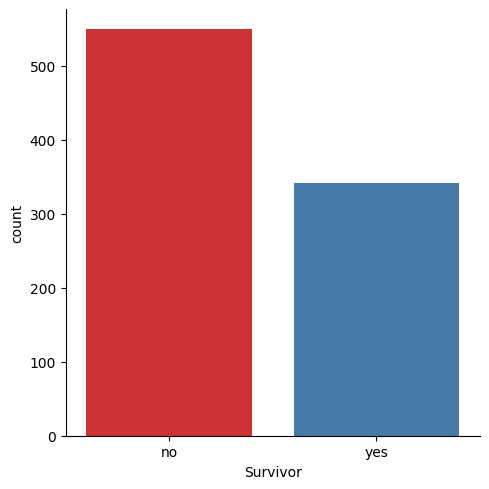

In [26]:
titanic_df['Survivor']= titanic_df.Survived.map({0:'no',1:'yes'})
sns.catplot(x='Survivor', data=titanic_df, hue='Survivor',palette='Set1', kind='count');                        

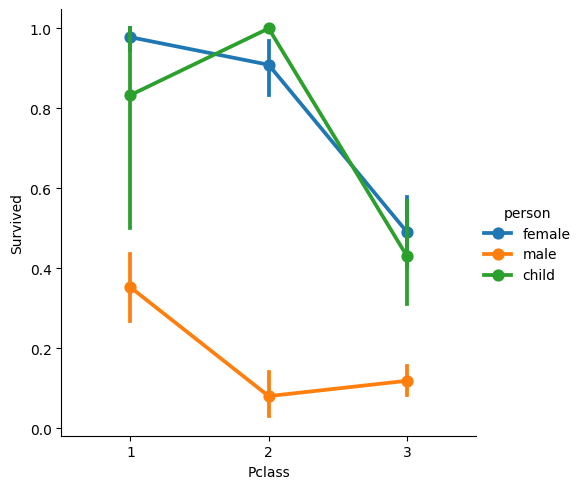

In [27]:
sns.catplot(x='Pclass', y='Survived', hue='person', data=titanic_df, kind='point');

The visualization reveals a clear pattern: female and child passengers had significantly higher survival probabilities than males across all classes. Additionally, passenger class played a substantial role in survival outcomes. Individuals in first class—particularly women and children—had the greatest likelihood of securing a lifeboat, reflecting social and logistical priorities during the evacuation. In contrast, males in lower classes faced the lowest survival rates, highlighting the intersection of gender and socioeconomic status in determining survival chances aboard the Titanic.

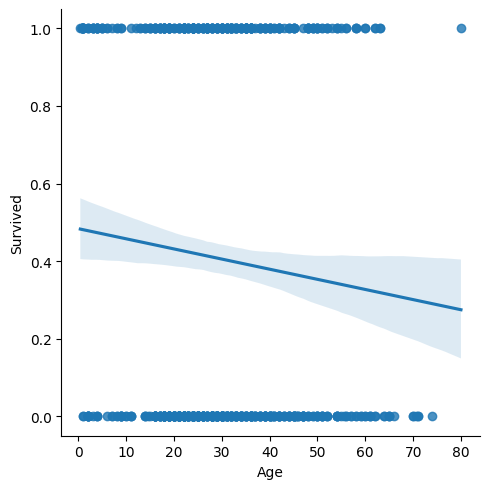

In [28]:
#| output: False
sns.lmplot(x='Age',y='Survived',data=titanic_df);

This plot suggests a negative correlation between age and survival rate—younger passengers were generally more likely to survive compared to older ones. However, given that the majority of passengers were male, it’s important to further analyze how age, passenger class, and gender interact to influence survival outcomes. In the next step, we’ll visualize these variables together to better understand how demographic and socioeconomic factors jointly affected the likelihood of survival.

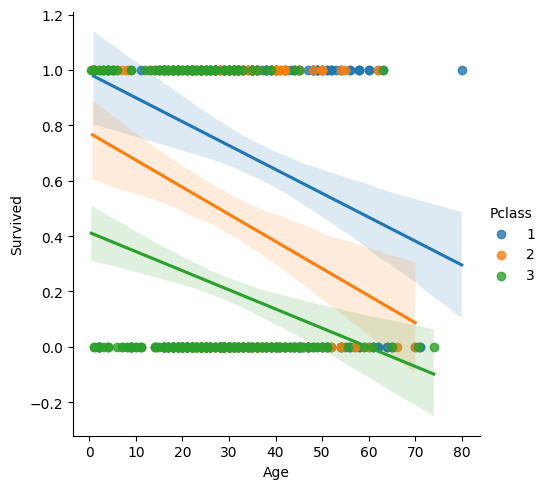

In [29]:
#| output: False
sns.lmplot(x='Age',y='Survived',hue='Pclass',data=titanic_df);

#### Analysis of Survival by Class and Age
The first plot, illustrating Survival Rate by Age, faceted by Passenger Class (Pclass), clearly demonstrates the dominant role of socio-economic status in survival outcomes. Regardless of age, First-Class (Pclass=1) passengers consistently had the highest probability of survival, followed by Second-Class, and then Third-Class. Furthermore, within each class, there is a distinct negative correlation between age and survival probability:

- Younger passengers (especially children, 0-10 years) in all classes showed a significantly higher chance of survival, reflecting the "women and
  children first" protocol.

- The survival probability for a First-Class passenger in their 60s is similar to or better than that of a Third-Class child around age 10.

- The overall trend shows survival probability decreasing as age increases, with the effect being most pronounced and the probability lowest for older   passengers in Third Class.

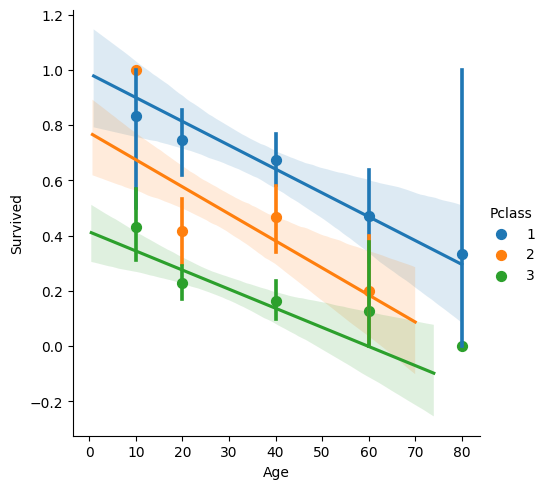

In [30]:
generations = [10,20,40,60,80]

sns.lmplot(x='Age',y='Survived', hue='Pclass', data = titanic_df, x_bins=generations);

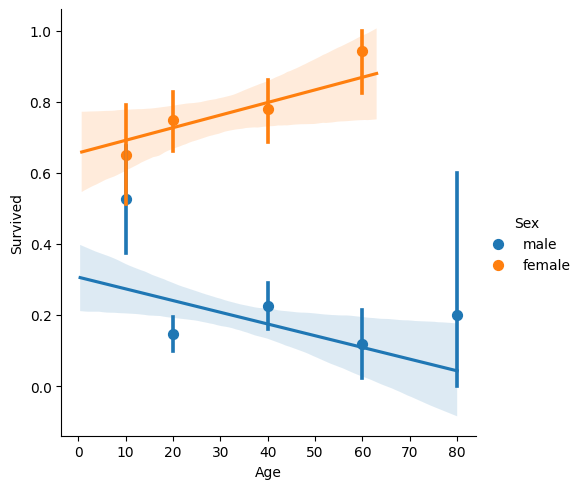

In [31]:
sns.lmplot(x='Age',y='Survived', hue='Sex', data = titanic_df, x_bins=generations);

#### Analysis of Survival by Gender and Age
The second plot, showing the Survival Rate by Age, faceted by Gender (Sex), highlights gender as the single most critical predictor of survival. Females had a dramatically higher survival rate across all age groups compared to males.

- The survival rate for females remains consistently high, generally between 60% and 95%, and even appears to slightly increase with age, suggesting
  older women were highly prioritized.

- Conversely, the survival rate for males is low across the board, typically below 35%. There is a clear negative trend for males: survival
  probability decreases as age increases, dropping to near zero for older men.

- This visualization powerfully reinforces the historical account of the sinking, where the "women and children first" rule was strictly enforced,
  resulting in a stark disparity in survival based on gender.

In [32]:
#| Output: False
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,person,Alone,Survivor
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male,With Family,no
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female,With Family,yes
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female,Alone,yes
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female,With Family,yes
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male,Alone,no


In [33]:
# Add cabin level column and grab the first character of the string
titanic_df['cabin_level']=titanic_df['Cabin'].str[0]

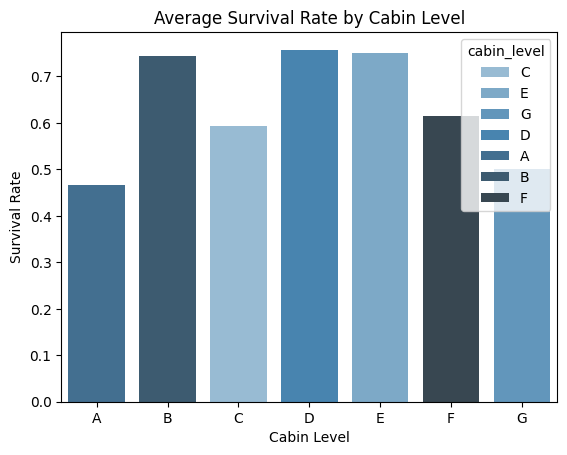

In [34]:
titanic_df_filtered = titanic_df[titanic_df['cabin_level'] != 'T']

sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='cabin_level',
    data=titanic_df_filtered,
    order=['A','B','C','D','E','F','G'],
    errorbar=None,
    palette='Blues_d'
)
plt.title('Average Survival Rate by Cabin Level')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level');

**Average Survival Rate by Cabin Level (Overall)**
- Higher Decks, Higher Survival: Survival rates are generally highest for passengers in Cabin Levels B, D, and E (all near or above 70%). This
  suggests that cabins on the higher decks, which are generally associated with First and Second Class, had better access to lifeboats.

- Lower Survival on Ends: Level A (highest) and F and G (lowest) show slightly lower or more varied survival rates, though still generally above 40%.
  The lowest overall survival rate belongs to Level A at approximately 47%.

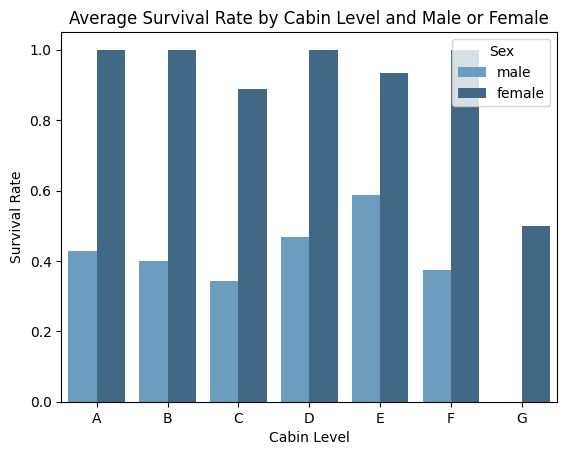

In [35]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Sex',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and Male or Female')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level');

**Average Survival Rate by Cabin Level and Male or Female**
- Gender Dominates: This plot reinforces that gender is the most powerful predictor of survival. In every single cabin level (A through G), the
  survival rate for females is dramatically higher (often approaching 100%) than the rate for males.

- Male Survival by Level: Male survival is low across the board, but is highest in Levels A, D, and E (around 45-60%). The lowest male survival is in
  Level C (around 35%).

- Female Survival: Female survival is consistently near 100% for Levels A, B, D, and F. It is marginally lower for Levels C, E, and G, but still
  remains very high (above 85%).

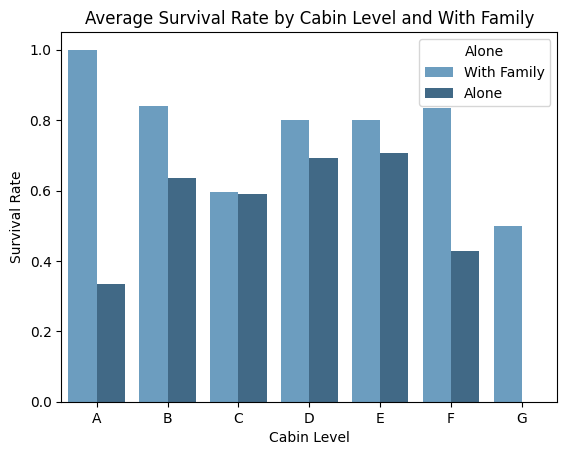

In [36]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Alone',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and With Family')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level');

**Average Survival Rate by Cabin Level and With Family**
- Survival with Company: For the majority of cabin levels (A, B, D, E, F), passengers traveling "With Family" (light blue) had a higher survival rate
  than those traveling "Alone" (dark blue).

- Contrasting Levels: In Level A, passengers with family had a perfect 100% survival rate, while those alone were around 35%. However, Levels C and E
  show very little difference between the "Alone" and "With Family" groups, suggesting the family factor had less impact on those specific decks.

In [37]:
titanic_df['Female_w_family']=np.where(
    (titanic_df['Sex']=='female') & (titanic_df['Alone'] == 'With Family'),
    'Female_w_family',
    'Alone')

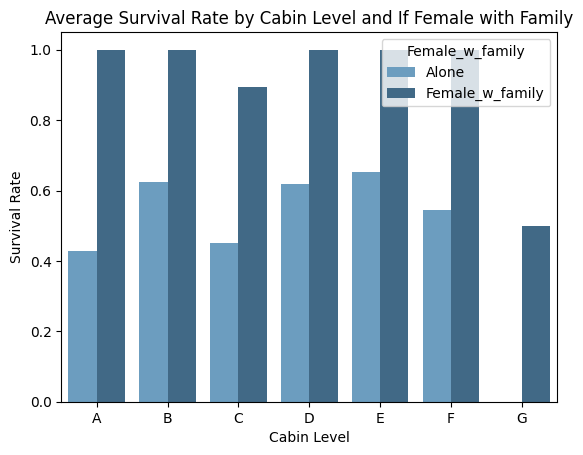

In [38]:
sns.barplot(
    x='cabin_level',
    y='Survived',
    hue='Female_w_family',
    data=titanic_df[titanic_df['cabin_level'] != 'T'],
    order=['A','B','C','D','E','F','G'],
    palette='Blues_d',
    errorbar=None
)

plt.title('Average Survival Rate by Cabin Level and If Female with Family')
plt.ylabel('Survival Rate')
plt.xlabel('Cabin Level');

**Average Survival Rate by Cabin Level and If Female with Family**  

- **Near-Perfect Survival:** This plot isolates the highest-priority group: Females traveling with family (dark blue). For every cabin level (A, B, D,   E,F), this group had a survival rate of 100%.

- **Female Alone:** The survival rate for Females alone (light blue) is still very high (well above 40%) but is significantly lower than that of the
  family group. This suggests that the combination of being female AND traveling with a family unit offered the maximum chance of survival, likely due
  to adherence to the "women and children first" protocol. The proximity and visibility of family units during the rescue likely factored into this
  outcome.

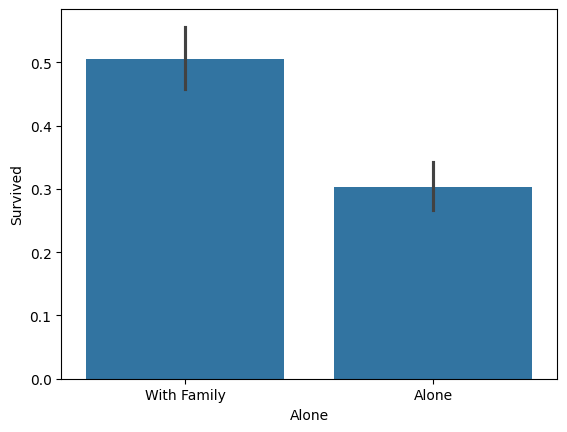

In [39]:
#Determining if there is a higher chance of survival if with family or alone
sns.barplot(x='Alone',y='Survived', data=titanic_df);

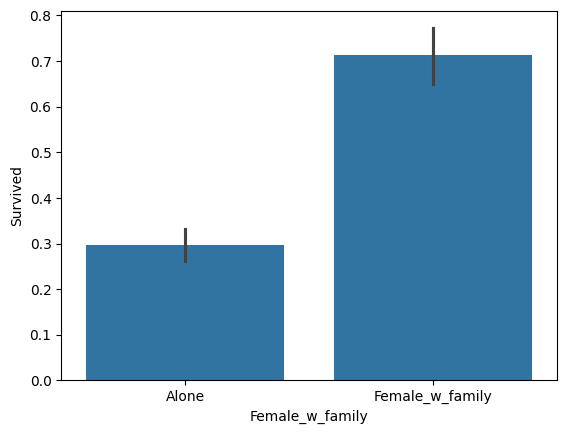

In [40]:
sns.barplot(x='Female_w_family',y='Survived', data=titanic_df);

#### Final Analysis: Impact of Family Status on Survival
These two bar plots isolate and confirm the relationship between a passenger's family status and their survival probability.

1. Survival Rate: With Family vs. Alone
The first plot demonstrates that traveling "With Family" significantly increased a passenger's overall chance of survival compared to traveling "Alone".

- Passengers traveling With Family had an average survival rate of approximately 50%.
- Passengers traveling Alone had an average survival rate of approximately 30%.


The difference suggests that the social dynamics on board or during the evacuation process favored individuals associated with a family unit, potentially benefiting from mutual assistance or being prioritized together during the rescue efforts.

2. Survival Rate: Females with Family vs. Alone
The second plot highlights the powerful compound effect when the "With Family" factor is combined with gender, validating the high-priority group identified in previous analyses.

- The survival rate for Females with Family is notably high, exceeding 70%.
- The survival rate for passengers Alone (without family) is significantly lower, at approximately 30%.

This stark disparity reinforces that the highest survival odds were afforded to passengers who satisfied the two most critical social criteria: being female and being part of a family unit. This outcome is a direct result of the strict enforcement of the "women and children first" protocol during the limited and chaotic lifeboat deployment.